In [98]:
from pathlib import Path
import calendar


import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [3]:
PATH_ASSIGNMENT1_DATA = Path("data")

# Customer Level

In [ ]:
train_targets = pd.read_csv(
    PATH_ASSIGNMENT1_DATA / "train_targets.csv", low_memory=False
)

In [5]:
train_targets.head()

,cust_id,revenue_2018_2019
0,7gnxbv6qflrjaf4y,398.65
1,lapyzcy7ih35kmyp,0.00
2,gl65ix4vdajwgt4q,0.00
3,v74tsfuqcldr2rqo,0.00
4,u6qowqu3fibkflon,0.00


so some customers have churned, i.e. they had at least one purchase in 2016-17 but did not return in 2018

In [6]:
train_targets["revenue_2018_2019"].max()

np.float64(1197.94)

In [7]:
train_targets["revenue_2018_2019"].min()

np.float64(0.0)

In [8]:
train_targets["revenue_2018_2019"].mode()

0    0.0
Name: revenue_2018_2019, dtype: float64

In [9]:
train_targets.describe()

,revenue_2018_2019
count,93272.000000
mean,70.175866
std,143.879835
min,0.000000
25%,0.000000
50%,0.000000
75%,80.960000
max,1197.940000


In [10]:
churned_percent = sum(train_targets["revenue_2018_2019"] == 0) / len(train_targets)

In [11]:
print(f"{churned_percent * 100:.2f}% of the customers have churned")

63.47% of the customers have churned


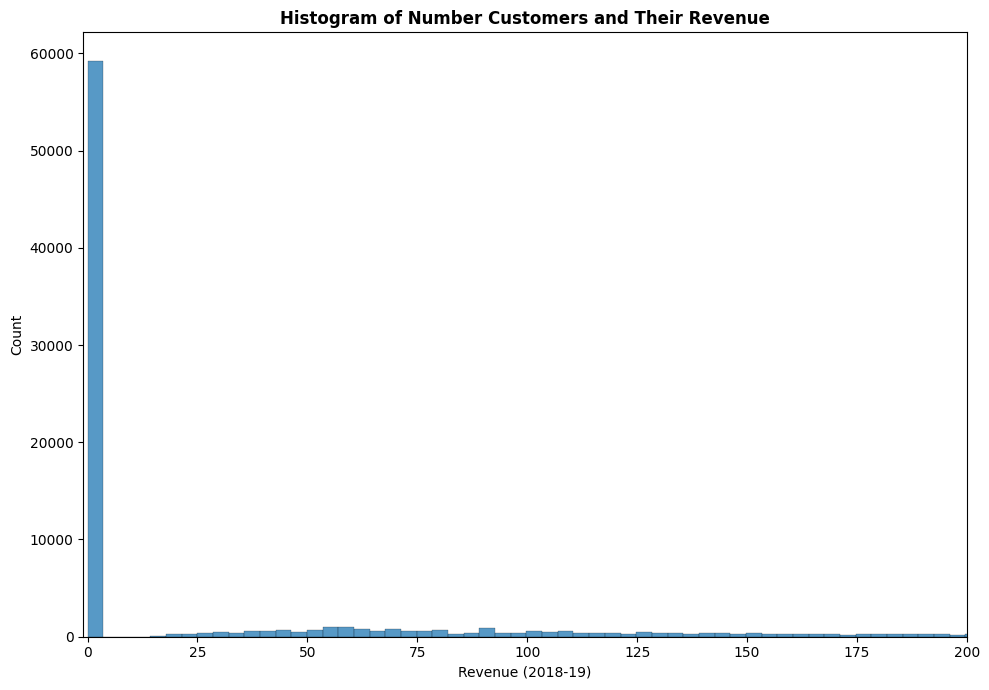

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.histplot(data=train_targets, ax=ax, x="revenue_2018_2019")
ax.set_title("Histogram of Number Customers and Their Revenue", fontweight="bold")
ax.set(xlabel="Revenue (2018-19)")
ax.set_xlim(-1, 200)

fig.tight_layout()

In [13]:
not_churned = train_targets[train_targets["revenue_2018_2019"] != 0]

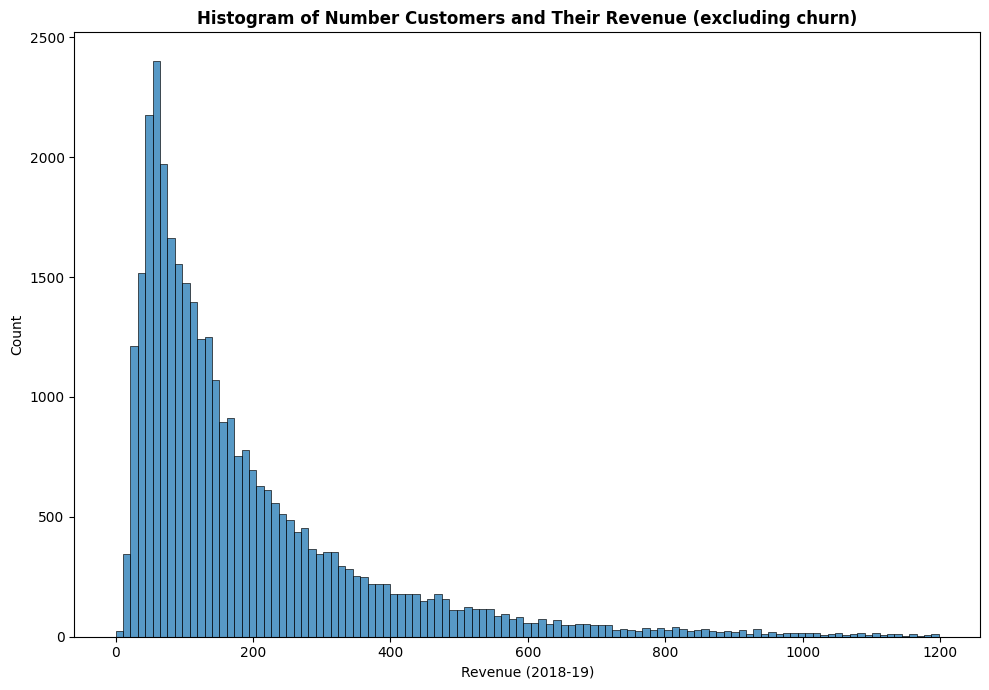

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.histplot(data=not_churned, ax=ax, x="revenue_2018_2019")
ax.set_title(
    "Histogram of Number Customers and Their Revenue (excluding churn)",
    fontweight="bold",
)
ax.set(xlabel="Revenue (2018-19)")

fig.tight_layout()

# Transaction Level

In [ ]:
df_train = pd.read_csv(
    PATH_ASSIGNMENT1_DATA / "train_clean.csv",
    low_memory=False,
    parse_dates=["order_date", "pack_date"],
)

In [67]:
df_train.head()

,cust_id,order_date,pack_date,sale_id,sale_discount_applied,sale_revenue,returned_to_shop_id,prod_id,prod_size,prod_web_only,...,prod_type_5,prod_heel,prod_material,prod_insole,prod_print,prod_comfort_sole,prod_comfort_wear,prod_clasp,prod_outlet,is_returned
0,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-35.70,83.30,NaN,543rj4mzzjnzkbil,30.0,0,...,boots (velcro),NaN,leather,1.0,NaN,NaN,NaN,velcro,0,0
1,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-39.98,0.00,ztodvuuaje,7ewnqhtrquent4cy,44.0,0,...,dress boots,NaN,leather,0.0,NaN,NaN,NaN,zipper,0,1
2,a63atwr2ig2jfprr,2016-01-01,2016-01-04,p4y4726y24dcxawf,-24.00,0.00,5tiaacoboa,cwtye5jwqr43a56i,38.5,0,...,lace-up shoes,NaN,suede,NaN,NaN,NaN,NaN,NaN,0,1
3,zr7ihbfbi6gcy2tz,2016-01-01,2016-01-05,3etkl2xv6pxku4kt,-26.23,43.72,NaN,mqw2seipp2wtylnw,35.0,0,...,velcro shoes,NaN,synthetic leather,0.0,NaN,NaN,breathable,velcro,0,0
4,dt7cthjqnjmkbiu6,2016-01-01,2016-01-05,lneitdgyfvrie3jo,-29.98,0.00,geja5b25na,5ut47kvr6zlx6y62,25.0,0,...,boots (velcro),NaN,NaN,NaN,NaN,NaN,NaN,velcro,0,1


In [68]:
df_train[["sale_revenue", "sale_discount_applied"]].describe()

,sale_revenue,sale_discount_applied
count,219128.000000,219128.000000
mean,53.150827,-20.642146
std,38.118486,22.447229
min,-89.950000,-198.750000
25%,27.570000,-31.500000
50%,53.000000,-12.000000
75%,75.950000,-4.590000
max,275.000000,1.000000


## `sale_revenue`

In [69]:
df_train[df_train["sale_revenue"] < 0].loc[:, ["sale_revenue", "is_returned"]]

,sale_revenue,is_returned
107,-5.00,1
154,-1.50,1
155,-5.88,1
198,-3.08,1
237,-1.40,1
...,...,...
217730,-5.00,1
217969,-0.91,1
217970,-1.09,1
218035,-5.00,1


In [70]:
df_train.loc[:, ["sale_revenue", "is_returned"]].corr()

,sale_revenue,is_returned
sale_revenue,1.000000,-0.666914
is_returned,-0.666914,1.000000


In [ ]:
df_train[(df_train["sale_revenue"] > 0) & (df_train["is_returned"] == 1)].loc[
    :, ["sale_revenue", "is_returned"]
]

,sale_revenue,is_returned
989,21.00,1
3636,11.50,1
4549,6.60,1
16256,1.24,1
16326,3.34,1
...,...,...
182489,0.50,1
182519,2.50,1
182575,2.05,1
182629,0.23,1


## `sale_discount_applied`

In [72]:
(df_train["sale_discount_applied"] > 0).sum()

np.int64(1)

there is a row in which the applied discount is 1

In [73]:
mask = df_train["sale_discount_applied"] > 0

In [74]:
df_train[mask]

,cust_id,order_date,pack_date,sale_id,sale_discount_applied,sale_revenue,returned_to_shop_id,prod_id,prod_size,prod_web_only,...,prod_type_5,prod_heel,prod_material,prod_insole,prod_print,prod_comfort_sole,prod_comfort_wear,prod_clasp,prod_outlet,is_returned
122718,zwmqge62dyjvigcc,2017-03-23,2017-03-24,gx4igp6kj2jlnydw,1.0,0.0,m4u2pedciy,ueyjufmqz6cfh3mj,32.0,0,...,low-top sneakers,<2.5 cm,leather,1.0,hearts,NaN,NaN,laces,0,1


## exploring `order_date `

In [ ]:
sales_revenue_by_month = df_train.groupby(df_train["order_date"].dt.month)[
    "sale_revenue"
].sum()

In [91]:
sales_revenue_by_month

order_date
1     1763593.68
2      452705.49
3      642227.61
4      930667.25
5      967085.96
6      971271.34
7     1562173.98
8      791604.70
9      798528.27
10     992220.86
11     725952.88
12    1048802.44
Name: sale_revenue, dtype: float64

In [ ]:
sales_revenue_by_month.index = [
    calendar.month_name[m] for m in sales_revenue_by_month.index
]

In [93]:
sales_revenue_by_month

January      1763593.68
February      452705.49
March         642227.61
April         930667.25
May           967085.96
June          971271.34
July         1562173.98
August        791604.70
September     798528.27
October       992220.86
November      725952.88
December     1048802.44
Name: sale_revenue, dtype: float64

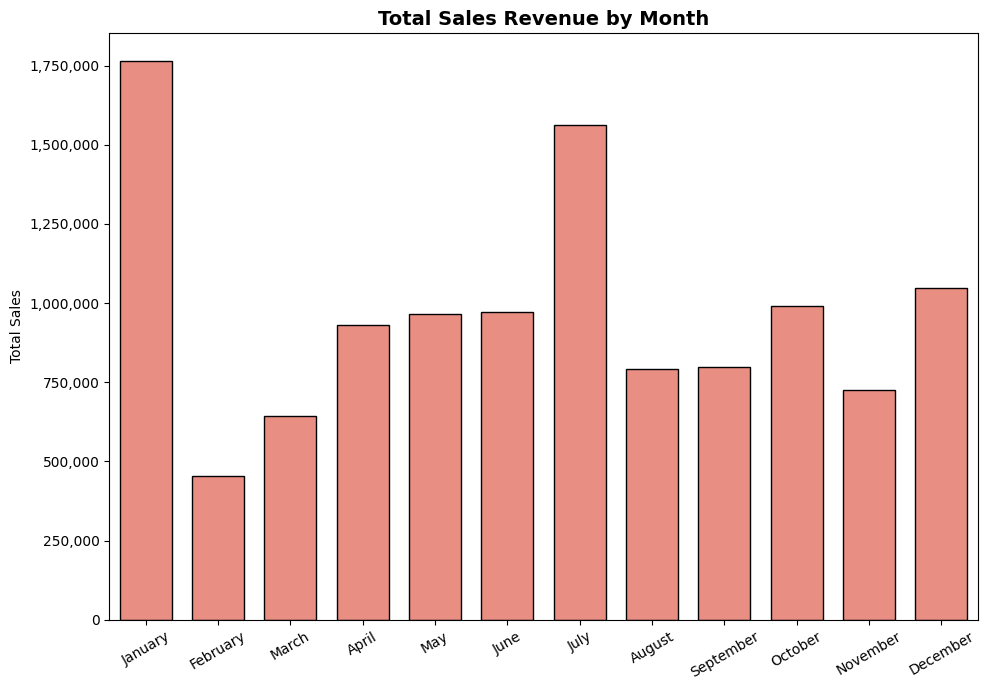

In [100]:
fig, ax = plt.subplots(figsize=(10, 7))


sns.barplot(data=sales_revenue_by_month, gap=0.1, color="salmon", edgecolor="black")  # type: ignore
ax.set_xticks(range(len(sales_revenue_by_month.index)))
ax.set_xticklabels(sales_revenue_by_month.index, rotation=30)

ax.set_title("Total Sales Revenue by Month", fontsize=14, fontweight="bold")
ax.set(ylabel="Total Sales")

fmt = "{x:,.0f}"
tick = mtick.StrMethodFormatter(fmt)
ax.yaxis.set_major_formatter(tick)

fig.tight_layout()